In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
df = pd.read_json("../results/results.json")

## Pie chart

Text(0.5, 1.0, 'Shot Type Distribution')

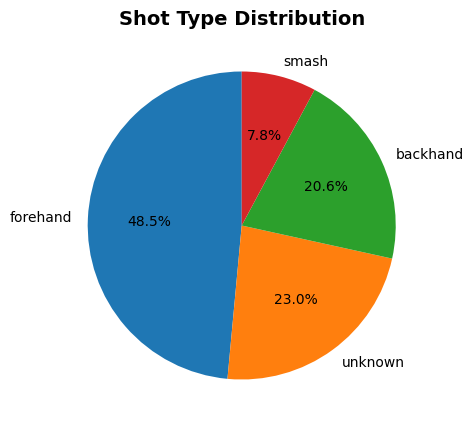

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))

shot_counts = df['shot_type'].value_counts()

ax.pie(shot_counts.values, labels=shot_counts.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Shot Type Distribution', fontsize=14, fontweight='bold')

## BarChart

In [28]:
shot_counts.plot(kind='bar', ax=ax2, color=colors)
ax.set_title('Shot Count by Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Shot Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

## Top 10 Players by Shot Count

Text(0, 0.5, 'Player ID')

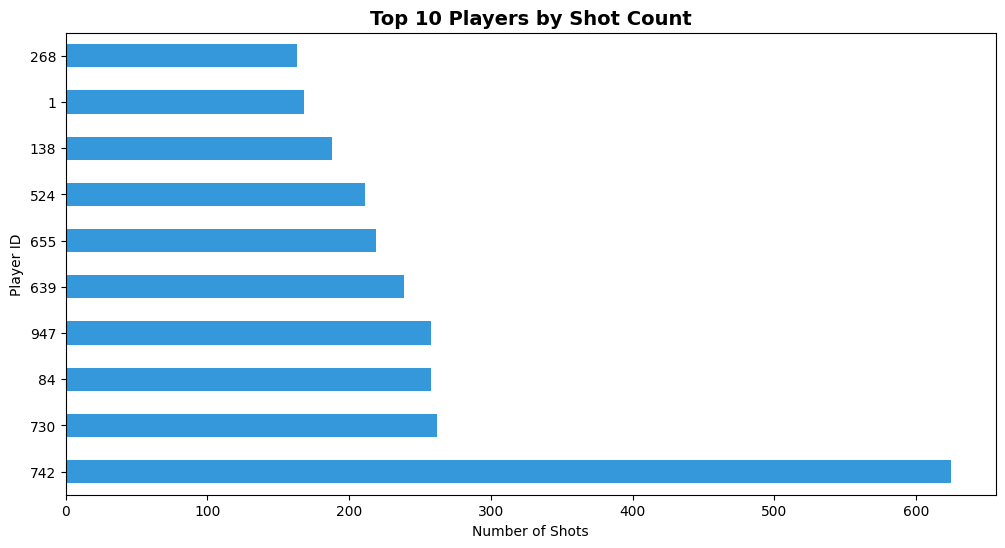

In [24]:
player_shots = df.groupby('player_id').size().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
player_shots.plot(kind='barh', ax=ax, color='#3498DB')
ax.set_title('Top 10 Players by Shot Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Shots')
ax.set_ylabel('Player ID')

## Shot Timeline

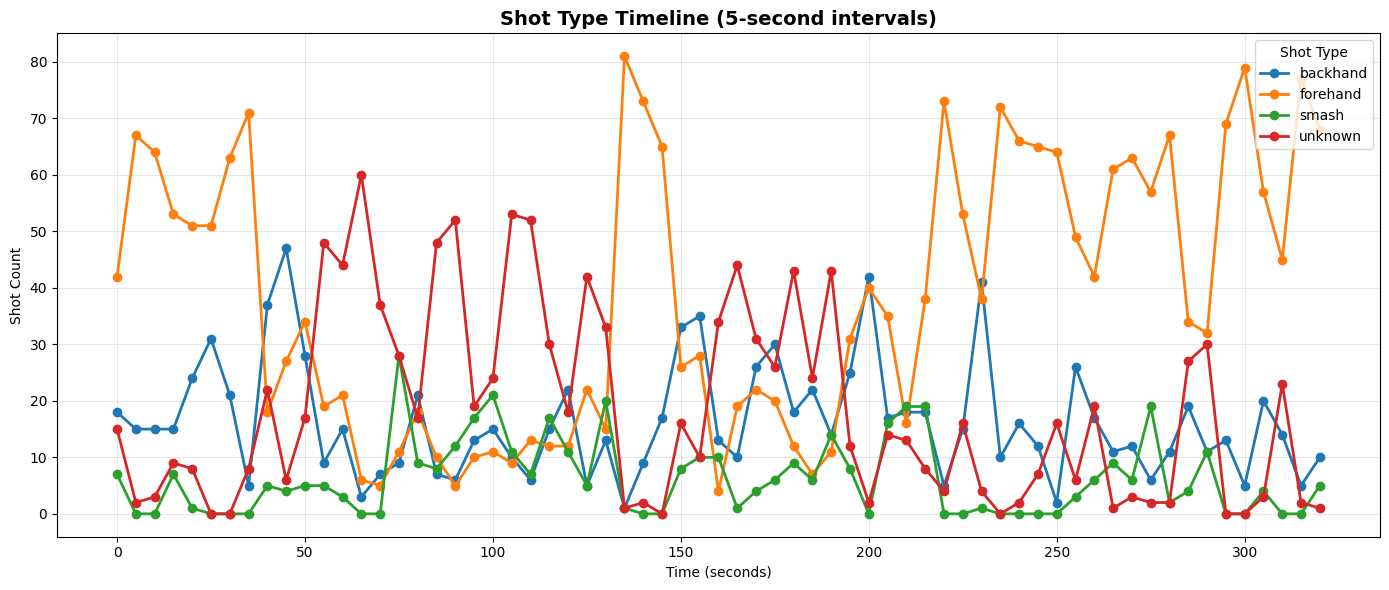

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))

# Group shots by time chunks
df['time_chunk'] = (df['timestamp'] // 5).astype(int) * 5
shot_timeline = df.groupby(['time_chunk', 'shot_type']).size().unstack(fill_value=0)

shot_timeline.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Shot Type Timeline (5-second intervals)', fontsize=14, fontweight='bold')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Shot Count')
ax.legend(title='Shot Type', loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()

## Top 5 Players by shot type

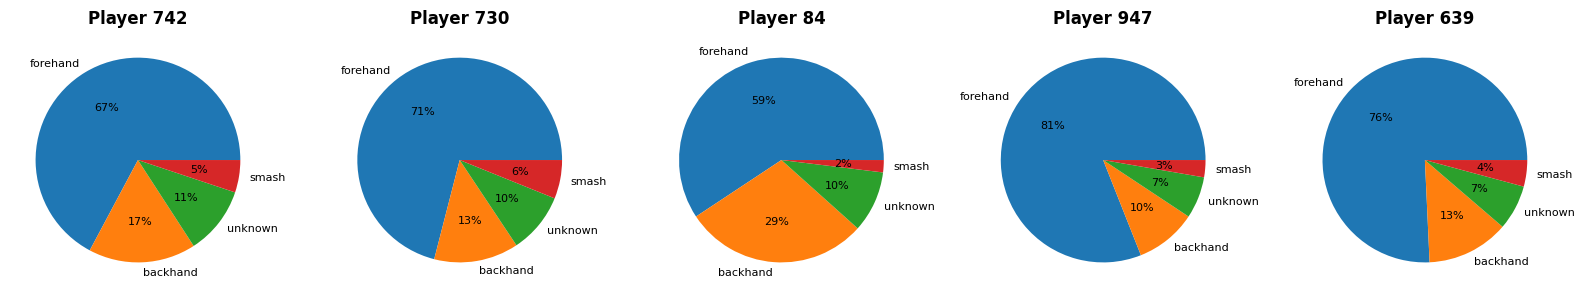

In [29]:
top_players = df.groupby('player_id').size().sort_values(ascending=False).head(5).index
top_player_data = df[df['player_id'].isin(top_players)]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for idx, player_id in enumerate(top_players):
    player_shots = top_player_data[top_player_data['player_id'] == player_id]['shot_type'].value_counts()
    axes[idx].pie(player_shots.values, labels=player_shots.index, autopct='%1.0f%%', textprops={'fontsize': 8})
    axes[idx].set_title(f'Player {player_id}', fontweight='bold')

plt.tight_layout()